In [12]:
# Load csv from lab2 
import numpy as np
import pandas as pd
df = pd.read_csv("../lab2/gaussian_bn_samples.csv")
df.head()

,X1,X2,X3,X4,X5
0,-0.469963,-1.298305,-0.260128,-1.030382,-0.855027
1,-0.074594,-0.349978,0.231659,0.347330,0.183078
2,0.059175,0.925056,0.525984,0.813671,0.302537
3,-0.206398,-0.254389,0.708236,-0.739022,-0.229203
4,-0.708556,-0.188118,-0.257136,-0.454381,-0.497639


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Covariance
Sigma = df.cov().values

# Precision matrix (inverse covariance)
Precision = np.linalg.inv(Sigma)

# Partial correlations: ρ_ij = -Θ_ij / sqrt(Θ_ii Θ_jj), where Θ = Precision
D = np.sqrt(np.diag(Precision))
partial_corr = -Precision / np.outer(D, D)

# Put into DataFrame for pretty display
pcorr_df = pd.DataFrame(partial_corr, index=df.columns, columns=df.columns)
pcorr_df


,X1,X2,X3,X4,X5
X1,-1.000000,0.445036,-0.191859,0.021264,-0.017998
X2,0.445036,-1.000000,-0.426248,0.308990,0.024181
X3,-0.191859,-0.426248,-1.000000,0.432608,-0.000336
X4,0.021264,0.308990,0.432608,-1.000000,0.806194
X5,-0.017998,0.024181,-0.000336,0.806194,-1.000000


In [16]:
Sigma

array([[ 1.0129251 ,  0.49781879, -0.31118668,  0.05757211,  0.06701814],
       [ 0.49781879,  0.74319843, -0.17454197,  0.30891008,  0.37695991],
       [-0.31118668, -0.17454197,  0.80932414,  0.5407401 ,  0.64082021],
       [ 0.05757211,  0.30891008,  0.5407401 ,  1.01662841,  1.21152153],
       [ 0.06701814,  0.37695991,  0.64082021,  1.21152153,  1.74584727]])

In [17]:
Precision

array([[ 1.58714663e+00, -9.55757688e-01,  4.19374475e-01,
        -7.17133561e-02,  4.12712757e-02],
       [-9.55757688e-01,  2.90594876e+00,  1.26071732e+00,
        -1.41002842e+00, -7.50274295e-02],
       [ 4.19374475e-01,  1.26071732e+00,  3.01039469e+00,
        -2.00930616e+00,  1.05983345e-03],
       [-7.17133561e-02, -1.41002842e+00, -2.00930616e+00,
         7.16604704e+00, -3.92811335e+00],
       [ 4.12712757e-02, -7.50274295e-02,  1.05983345e-03,
        -3.92811335e+00,  3.31290785e+00]])

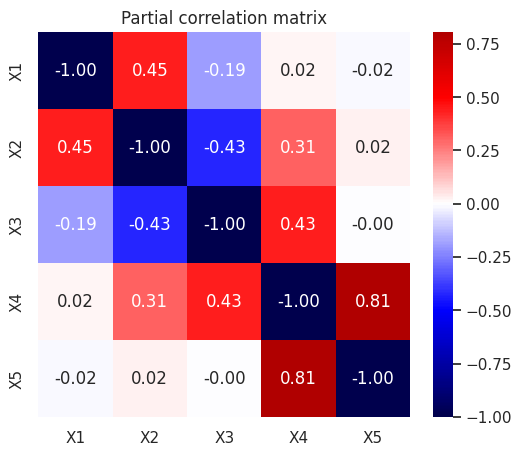

In [6]:
plt.figure(figsize=(6,5))
sns.heatmap(pcorr_df, annot=True, fmt=".2f", center=0, cmap="seismic")
plt.title("Partial correlation matrix")
plt.show()
